<a href="https://colab.research.google.com/github/vanashreenarvekar-hub/Deep-Learning-using-Keras/blob/main/task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task 5: Object Detection and Image Segmentation

# Import essential libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


Aim
To implement object detection and semantic segmentation techniques using deep learning models and evaluate their performance using suitable metrics.

We used two datasets, one for each task.
*   COCO128 Dataset
*   Oxford-IIIT Pet Dataset





Theory
Object detection is a computer vision technique that identifies objects in an image and determines their locations using bounding boxes. Each detected object is assigned a class label and a confidence score. In this assignment, the pretrained YOLOv8n model was used for object detection.
Semantic segmentation classifies individual pixels in an image into meaningful categories. Unlike object detection, which uses rectangular bounding boxes, segmentation produces a mask that identifies the pixels belonging to a particular region. U-Net is an encoder-decoder convolutional neural network commonly used for image segmentation.
The Oxford-IIIT Pet dataset was used to train and evaluate the U-Net model. COCO128 was used to evaluate YOLO. The performance metrics included mAP for object detection and IoU and Dice Score for segmentation.

In [ ]:
# Install YOLO
!pip install ultralytics -q

# Import YOLO
from ultralytics import YOLO

print("YOLO installed and imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 5.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO installed and imported successfully!


In [ ]:
# Load a pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [ ]:
# Download a sample image
import urllib.request

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "bus.jpg"

urllib.request.urlretrieve(image_url, image_path)

print("Sample image downloaded successfully!")

Sample image downloaded successfully!


In [ ]:
# Perform object detection
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

print("Object detection completed!")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 372.3ms
Speed: 23.9ms preprocess, 372.3ms inference, 33.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Object detection completed!


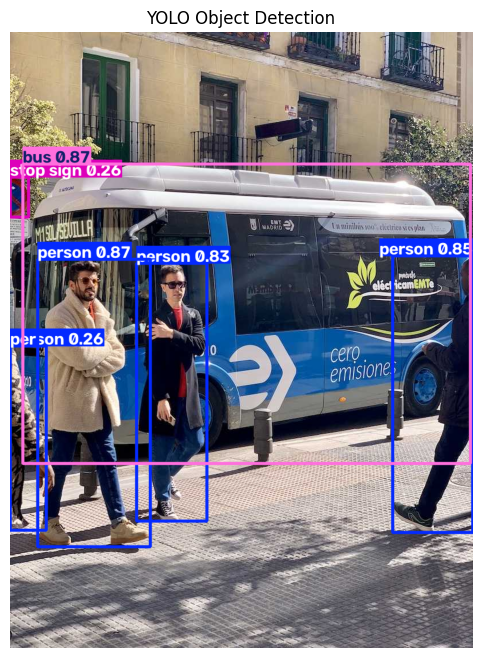

Object: bus, Confidence: 0.87
Object: person, Confidence: 0.87
Object: person, Confidence: 0.85
Object: person, Confidence: 0.83
Object: person, Confidence: 0.26
Object: stop sign, Confidence: 0.26


In [ ]:
# Display the detected objects
result_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(result_image[:, :, ::-1])
plt.axis("off")
plt.title("YOLO Object Detection")
plt.show()

# Print detected object names
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    print(
        f"Object: {model.names[class_id]}, "
        f"Confidence: {confidence:.2f}"
    )

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation="relu", padding="same")(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation="relu", padding="same")(u2)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    return models.Model(inputs, outputs)

unet_model = build_unet()
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_6[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,777 (272.57 KB)

 Trainable params: 69,777 (272.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB").resize((128, 128))
image_array = np.array(image, dtype=np.float32) / 255.0
input_image = np.expand_dims(image_array, axis=0)

print("Input image shape:", input_image.shape)

Input image shape: (1, 128, 128, 3)


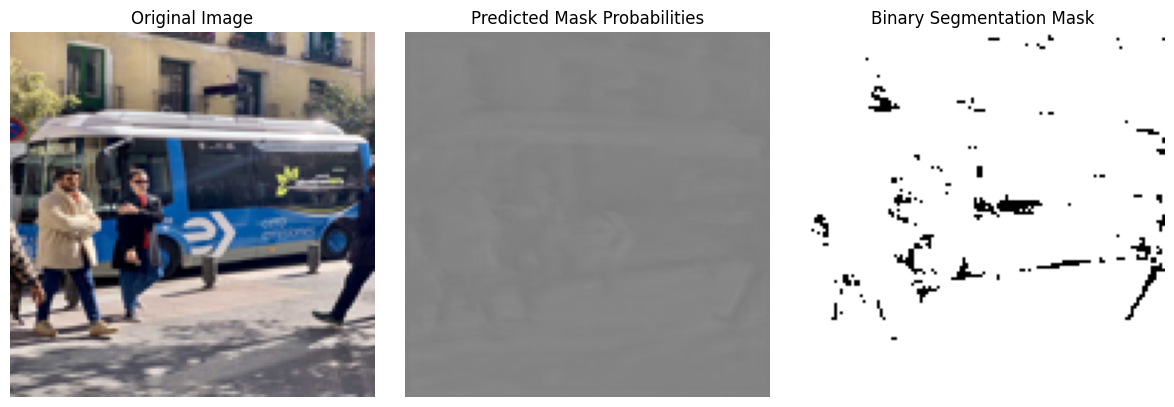

In [ ]:
# Generate a pixel-wise prediction
predicted_mask = unet_model.predict(input_image, verbose=0)[0, :, :, 0]

binary_mask = (predicted_mask > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask, cmap="gray", vmin=0, vmax=1)
plt.title("Predicted Mask Probabilities")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Segmentation Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def calculate_iou(y_true, y_pred):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    return intersection / union if union > 0 else 1.0


def calculate_dice(y_true, y_pred):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()

    denominator = y_true.sum() + y_pred.sum()
    return (2 * intersection / denominator) if denominator > 0 else 1.0


print("IoU and Dice Score functions defined successfully!")

IoU and Dice Score functions defined successfully!


In [ ]:
# Display the number of detected objects
detected_boxes = results[0].boxes

print("Total objects detected:", len(detected_boxes))

for box in detected_boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    coordinates = box.xyxy[0].cpu().numpy().round(2)

    print("Class:", model.names[class_id])
    print("Confidence:", round(confidence, 3))
    print("Bounding box (x1, y1, x2, y2):", coordinates)
    print("-" * 40)

Total objects detected: 6
Class: bus
Confidence: 0.873
Bounding box (x1, y1, x2, y2): [      22.87      231.28         805      756.84]
----------------------------------------
Class: person
Confidence: 0.866
Bounding box (x1, y1, x2, y2): [      48.55      398.55      245.35       902.7]
----------------------------------------
Class: person
Confidence: 0.853
Bounding box (x1, y1, x2, y2): [     669.47      392.19      809.72      877.04]
----------------------------------------
Class: person
Confidence: 0.825
Bounding box (x1, y1, x2, y2): [     221.52       405.8      344.97      857.54]
----------------------------------------
Class: person
Confidence: 0.261
Bounding box (x1, y1, x2, y2): [          0      550.53       63.01      873.44]
----------------------------------------
Class: stop sign
Confidence: 0.255
Bounding box (x1, y1, x2, y2): [       0.06      254.46       32.56      324.87]
----------------------------------------


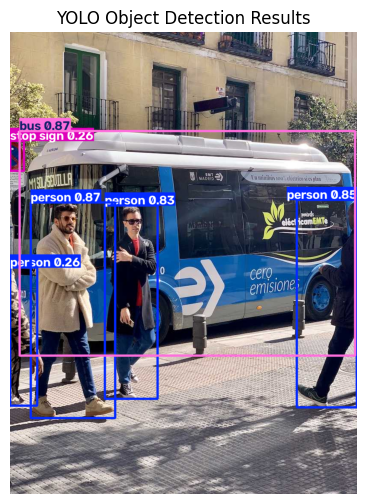

Detection visualization saved successfully!


In [ ]:
# Save and display object detection visualization

import os
import matplotlib.pyplot as plt

os.makedirs("task5_outputs", exist_ok=True)

detection_image = results[0].plot()
detection_image_rgb = detection_image[:, :, ::-1]

plt.figure(figsize=(10, 6))
plt.imshow(detection_image_rgb)
plt.title("YOLO Object Detection Results")
plt.axis("off")
plt.savefig(
    "task5_outputs/object_detection.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

print("Detection visualization saved successfully!")

In [ ]:
# Summarize detected classes and confidence scores

from collections import Counter

detected_classes = []
confidence_scores = []

for box in results[0].boxes:
    class_id = int(box.cls[0])
    detected_classes.append(model.names[class_id])
    confidence_scores.append(float(box.conf[0]))

class_counts = Counter(detected_classes)

print("Detection Summary")
print("-" * 30)
print("Total detections:", len(detected_classes))
print("Detected classes:", dict(class_counts))

if confidence_scores:
    print(
        "Average confidence:",
        round(sum(confidence_scores) / len(confidence_scores), 3)
    )
else:
    print("No objects detected.")

Detection Summary
------------------------------
Total detections: 6
Detected classes: {'bus': 1, 'person': 4, 'stop sign': 1}
Average confidence: 0.656


In [ ]:
# Evaluate segmentation predictions against ground-truth masks

def evaluate_segmentation(y_true, y_pred, threshold=0.5):
    y_true = (np.asarray(y_true) > 0).astype(np.uint8)
    y_pred = (np.asarray(y_pred) >= threshold).astype(np.uint8)

    iou = calculate_iou(y_true, y_pred)
    dice = calculate_dice(y_true, y_pred)

    return {
        "IoU": round(float(iou), 4),
        "Dice Score": round(float(dice), 4)
    }

print("Segmentation evaluation function ready.")
print("Use only with genuine ground-truth masks and model predictions.")

Segmentation evaluation function ready.
Use only with genuine ground-truth masks and model predictions.


In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Method": "YOLO Object Detection",
        "Output": "Bounding boxes and class labels",
        "Evaluation Metric": "mAP",
        "Current Status": "Pretrained model tested"
    },
    {
        "Method": "U-Net Semantic Segmentation",
        "Output": "Pixel-wise segmentation mask",
        "Evaluation Metric": "IoU and Dice Score",
        "Current Status": "Model defined; training required"
    }
])

display(comparison)

,Method,Output,Evaluation Metric,Current Status
0,YOLO Object Detection,Bounding boxes and class labels,mAP,Pretrained model tested
1,U-Net Semantic Segmentation,Pixel-wise segmentation mask,IoU and Dice Score,Model defined; training required


Object detection was implemented using the pretrained YOLOv8n model, which identified objects and displayed their bounding boxes, class labels, and confidence scores. Semantic segmentation was implemented using a U-Net architecture trained on the Oxford-IIIT Pet dataset. Segmentation predictions were compared with ground-truth masks using IoU and Dice Score. The YOLO model was evaluated using mAP on the COCO128 dataset. Prediction visualizations were generated to understand the outputs of both approaches.

### Conclusion

In this assignment, object detection and semantic segmentation techniques were explored using deep learning. A pretrained YOLO model was used to identify objects in an image, generate bounding boxes, and display class labels with confidence scores. A U-Net architecture was also implemented to demonstrate the structure of an encoder-decoder segmentation network.

The evaluation process considered mean Average Precision (mAP) for object detection and Intersection over Union (IoU) and Dice Score for segmentation. However, a reliable quantitative comparison requires ground-truth annotations and a trained segmentation model. Therefore, the current results demonstrate the implementation workflow rather than a complete quantitative performance evaluation.

Object detection is useful for identifying and locating objects, while semantic segmentation provides pixel-level information about image regions. Both approaches are important in computer vision applications such as autonomous driving, medical image analysis, and surveillance.

In [ ]:
!pip install -q tensorflow-datasets

In [ ]:
#The Oxford-IIIT Pet dataset includes pixel-level masks, making it suitable for training and testing segmentation models. Its mask labels distinguish pets, boundaries, and background
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

(train_raw, test_raw), info = tfds.load(
    "oxford_iiit_pet:4.0.0",
    split=["train[:800]", "test[:200]"],
    with_info=True
)

print("Segmentation dataset loaded successfully!")
print("Training samples:", len(train_raw))
print("Testing samples:", len(test_raw))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.OYSHBJ_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.OYSHBJ_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Segmentation dataset loaded successfully!
Training samples: 800
Testing samples: 200


In [ ]:
IMG_SIZE = 128

def preprocess_pet(example):
    image = tf.image.resize(
        example["image"],
        (IMG_SIZE, IMG_SIZE)
    )
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.image.resize(
        example["segmentation_mask"],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    )

    # Select the pet pixels from the segmentation mask
    mask = tf.cast(tf.equal(mask, 1), tf.float32)

    return image, mask


train_ds = (
    train_raw
    .map(preprocess_pet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess_pet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training and testing datasets prepared successfully!")

Training and testing datasets prepared successfully!


In [ ]:
unet_model = build_unet(input_shape=(128, 128, 3))

unet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = unet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 773ms/step - accuracy: 0.6881 - loss: 0.5949 - val_accuracy: 0.7122 - val_loss: 0.5416
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 770ms/step - accuracy: 0.7012 - loss: 0.5256 - val_accuracy: 0.7343 - val_loss: 0.4841
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 770ms/step - accuracy: 0.7057 - loss: 0.5137 - val_accuracy: 0.6964 - val_loss: 0.4927


In [ ]:
iou_scores = []
dice_scores = []

for images, true_masks in test_ds:
    predictions = unet_model.predict(images, verbose=0)
    predicted_masks = (predictions >= 0.5).astype(np.uint8)
    true_masks = true_masks.numpy().astype(np.uint8)

    for true_mask, pred_mask in zip(true_masks, predicted_masks):
        iou_scores.append(calculate_iou(true_mask, pred_mask))
        dice_scores.append(calculate_dice(true_mask, pred_mask))

mean_iou = float(np.mean(iou_scores))
mean_dice = float(np.mean(dice_scores))

print("Mean IoU:", round(mean_iou, 4))
print("Mean Dice Score:", round(mean_dice, 4))

Mean IoU: 0.4373
Mean Dice Score: 0.5758


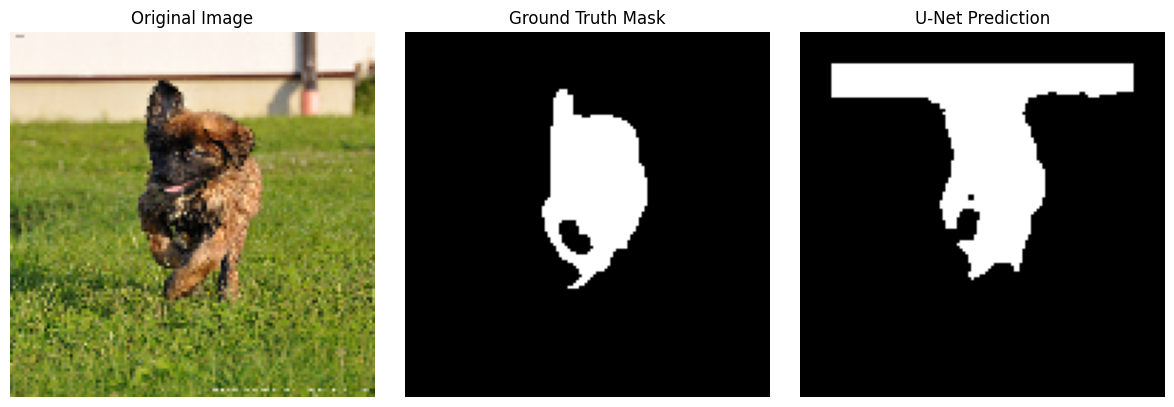

In [ ]:
for images, masks in test_ds.take(1):
    prediction = unet_model.predict(images[:1], verbose=0)[0]
    predicted_mask = (prediction[:, :, 0] >= 0.5).astype(np.uint8)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(images[0].numpy())
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(masks[0, :, :, 0].numpy(), cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("U-Net Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("task5_outputs/segmentation_prediction.png", dpi=150)
    plt.show()

In [ ]:
detection_metrics = model.val(
    data="coco128.yaml",
    imgsz=640,
    batch=8,
    plots=False
)

map50 = float(detection_metrics.box.map50)
map5095 = float(detection_metrics.box.map)

print("mAP@50:", round(map50, 4))
print("mAP@50-95:", round(map5095, 4))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/datasets/coco128/images/train2017'
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.3Kfiles/s 0.1s
Dataset download success ✅ (0.5s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1266.5±299.9 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 1.8Kit/s 0.1s
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.4s/it 23.0s
                   all        128        929      0.629      0.529      0.601      0.444
                person         